# Segmentación de Otsu con validación cruzada de **K = 5**

Aplica **Otsu** a todas las imágenes de `DATASET_FINAL.mat` siguiendo el **mismo protocolo**
que las CNN y los transformers del TFG:

* validación cruzada **estratificada por tipo de lesión**, K = 5 pliegues
* reparto por pliegue: **64 %** entrenamiento / **16 %** validación / **20 %** test
* cada imagen actúa como test exactamente una vez
* métricas reportadas como **media**

Al terminar, se muestran 5 imágenes con cuatro paneles cada una:

**Original · Segmentación Otsu · Ground truth · Contornos superpuestos**

(**verde** = contorno del ground truth, **rojo** = contorno de Otsu).


### 1. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Parámetros

In [ ]:
RUTA_MAT       = "/C:/Users/josem/Desktop/DATASET_FINAL.pdf"
CARPETA_SALIDA = "/content/drive/MyDrive/TFG/resultados_otsu"

UMBRAL_DICE   = 0.9      # solo se muestran las imágenes que superen este Dice
MAX_MOSTRAR   = 5       # tope de filas en la figura (None = todas). Evita generar
                         # una figura gigantesca si muchas imágenes pasan el filtro.
POSTPROCESO   = True     # limpieza morfológica + mayor componente conexa
RELLENAR      = True     # rellena los huecos negros dentro de la lesión
GUARDAR       = True     # guardar la figura en CARPETA_SALIDA

REDIMENSIONAR = True     # 256x256, como el resto del pipeline del TFG.
IMG_SIZE      = 256      # Ponlo a False para trabajar a resolución nativa
                         # (figuras más nítidas, métricas ligeramente distintas).

# --- validación cruzada ---
N_SPLITS      = 5        # K = 5 pliegues
VAL_FRACTION  = 0.20     # 20 % del 80 % restante = 16 % del total
RANDOM_STATE  = 42       # semilla fija -> pliegues reproducibles

# Espacio de búsqueda de la configuración de Otsu: (canal, polaridad).
#   polaridad = 1 -> la lesión es la clase de intensidad ALTA en ese canal
#   polaridad = 0 -> es la clase BAJA
CONFIGS_CANDIDATAS = [
    ("lab_a", 1),   # crominancia rojo-verde: los hemangiomas son rojizos
    ("lab_a", 0),
    ("hsv_s", 1),   # saturación
    ("gris",  0),   # intensidad: la lesión suele ser más oscura que la piel
    ("gris",  1),
    ("rgb_r", 1),   # canal rojo
    ("inv_g", 1),   # verde invertido, realza lo rojizo
]

### 3. Importaciones

In [ ]:
import os
import h5py
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes
from sklearn.model_selection import StratifiedKFold, train_test_split
from collections import Counter

### 4. Lectura del dataset

Se cargan **todas** las entradas (no una selección), porque la validación cruzada necesita el
conjunto completo.

In [ ]:
f  = h5py.File(RUTA_MAT, "r")
DS = f["DATASET_UNIDO"]

def leer_entrada(i):
    c = [f[r] for r in f[DS[i, 0]][()].ravel()]
    nombre = "".join(chr(x) for x in c[0][()].ravel())
    tipo   = "".join(chr(x) for x in c[2][()].ravel())
    mask   = (c[1][()].T > 0).astype(np.uint8)                          # (H, W) binaria
    img    = (np.transpose(c[3][()], (2, 1, 0)) * 255).clip(0, 255).astype(np.uint8)
    return nombre, tipo, img, mask


N = DS.shape[0]
nombres, tipos, imagenes, mascaras = [], [], [], []

for i in range(N):
    nombre, tipo, img, gt = leer_entrada(i)
    if REDIMENSIONAR:
        # área para la imagen, vecino más próximo para la máscara,
        # que así conserva su carácter estrictamente binario
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        gt  = cv2.resize(gt,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    nombres.append(nombre)
    tipos.append(tipo)
    imagenes.append(img)
    mascaras.append((gt > 0).astype(np.uint8))

etiquetas = np.array(tipos)

### 5. Segmentación de Otsu

In [ ]:
def extraer_canal(img, canal):
    """Devuelve el canal escalar uint8 sobre el que se umbraliza."""
    if canal == "gris":
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if canal == "lab_a":
        return cv2.cvtColor(img, cv2.COLOR_RGB2LAB)[:, :, 1]
    if canal == "hsv_s":
        return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)[:, :, 1]
    if canal == "rgb_r":
        return img[:, :, 0]
    if canal == "inv_g":
        return 255 - img[:, :, 1]
    raise ValueError(f"canal desconocido: {canal}")


def segmentar_otsu(img, canal="lab_a", polaridad=1, postproceso=True, rellenar=True):
    """Otsu selecciona automáticamente el umbral que maximiza la varianza entre las
    dos clases del histograma (equivalentemente, minimiza la varianza intraclase)."""
    ch = cv2.GaussianBlur(extraer_canal(img, canal), (5, 5), 0)

    flag = cv2.THRESH_BINARY if polaridad == 1 else cv2.THRESH_BINARY_INV
    _, seg = cv2.threshold(ch, 0, 1, flag + cv2.THRESH_OTSU)
    seg = seg.astype(np.uint8)

    if postproceso:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        seg = cv2.morphologyEx(seg, cv2.MORPH_OPEN, k)
        seg = cv2.morphologyEx(seg, cv2.MORPH_CLOSE, k)
        n, lbl = cv2.connectedComponents(seg)
        if n > 2:                       # conserva la mayor componente conexa
            areas = [(lbl == j).sum() for j in range(1, n)]
            seg = (lbl == 1 + int(np.argmax(areas))).astype(np.uint8)

    if rellenar:
        seg = binary_fill_holes(seg).astype(np.uint8)   # tapa huecos interiores

    return seg.astype(np.uint8)

### 6. Métricas y dibujo de contornos

In [ ]:
EPS = 1e-8
P = 1.2
def matriz_confusion(pred, gt):
    """Recuento de VP, VN, FP y FN a nivel de píxel."""
    p, g = pred > 0, gt > 0
    return dict(vp=int(( p &  g).sum()), vn=int((~p & ~g).sum()),
                fp=int(( p & ~g).sum()), fn=int((~p &  g).sum()))

def suma_confusion(a, b):
    return {k: a[k] + b[k] for k in a}

def dice_de_confusion(c):
    return (2 * c["vp"] + EPS) / (2 * c["vp"] + c["fp"] + c["fn"] + EPS)

def metricas_de_confusion(c):
    return {
        "exactitud":    (c["vp"] + c["vn"]) / (c["vp"] + c["vn"] + c["fp"] + c["fn"] + EPS),
        "precision":    (c["vp"] + EPS) / (c["vp"] + c["fp"]+ EPS),
        "sensibilidad":   (c["vp"] + EPS) / (c["vp"] + c["fn"] + EPS),
        "especificidad": (c["vn"] + EPS) / (c["vn"] + c["fp"] + EPS),
    }

def dice(a, b):
    return dice_de_confusion(matriz_confusion(a, b))


def evaluar(indices, canal, polaridad):
    """Evalúa una configuración de Otsu sobre un subconjunto de índices.

    Distingue las dos formas de agregar, tal y como se explica en §6.2 de la memoria:
      * Dice -> se calcula por imagen y se promedia (macro). Cada lesión pesa igual.
      * F1   -> se acumulan VP, FP y FN de todas las imágenes y se calcula una sola
                vez sobre el total (micro). Cada píxel pesa igual, así que las
                lesiones grandes influyen más.
    Por eso Dice y F1 comparten fórmula pero no valor."""
    dices, total = [], dict(vp=0, vn=0, fp=0, fn=0)
    for i in indices:
        seg = segmentar_otsu(imagenes[i], canal, polaridad, POSTPROCESO, RELLENAR)
        c = matriz_confusion(seg, mascaras[i])
        dices.append(dice_de_confusion(c))
        total = suma_confusion(total, c)
    res = metricas_de_confusion(total)
    res["dice"] = float(np.mean(dices))   # macro, por imagen
    res["f1"]   = dice_de_confusion(total)  # micro, global
    return res


def elegir_configuracion(indices_ajuste):
    """Elige la configuración que maximiza el Dice en entrenamiento + validación.
    Ninguna imagen de test interviene en esta decisión."""
    mejor, mejor_dice = None, -1.0
    for canal, polaridad in CONFIGS_CANDIDATAS:
        d = evaluar(indices_ajuste, canal, polaridad)["dice"]
        if d > mejor_dice:
            mejor, mejor_dice = (canal, polaridad), d
    return mejor, mejor_dice


def dibujar_contornos(img, seg, gt, grosor=None):
    o = img.copy()
    if grosor is None:
        grosor = max(2, int(round(max(img.shape[:2]) / 300)))   # grosor según tamaño
    cont_gt,  _ = cv2.findContours(gt.astype(np.uint8),  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cont_seg, _ = cv2.findContours(seg.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cv2.drawContours(o, cont_gt,  -1, (255, 0, 0), grosor)   # ground truth -> rojo
    cv2.drawContours(o, cont_seg, -1, (0, 255, 0), grosor)   # Otsu         -> verde
    return o

### 7. Validación cruzada estratificada de 5 pliegues

In [ ]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

resultados_pliegue = []
configs_elegidas   = []

# predicción fuera de pliegue para cada imagen
seg_oof    = [None] * N
dice_oof   = np.zeros(N)
pliegue_de = np.zeros(N, dtype=int)

print(f"Validación cruzada estratificada de {N_SPLITS} pliegues\n")

for pliegue, (idx_trval, idx_test) in enumerate(skf.split(np.zeros(N), etiquetas), 1):
    # Separación interna entrenamiento / validación (16 % del total)
    try:
        idx_train, idx_val = train_test_split(
            idx_trval, test_size=VAL_FRACTION,
            stratify=etiquetas[idx_trval], random_state=RANDOM_STATE)
    except ValueError:
        # alguna clase tiene muy pocas muestras para estratificar el subreparto
        idx_train, idx_val = train_test_split(
            idx_trval, test_size=VAL_FRACTION, random_state=RANDOM_STATE)

    # La configuración se decide sobre entrenamiento + validación...
    (canal, polaridad), dice_ajuste = elegir_configuracion(
        np.concatenate([idx_train, idx_val]))
    # ...y se aplica al pliegue de test, no visto en la selección.
    res = evaluar(idx_test, canal, polaridad)

    for i in idx_test:
        s = segmentar_otsu(imagenes[i], canal, polaridad, POSTPROCESO, RELLENAR)
        seg_oof[i]    = s
        dice_oof[i]   = dice(s, mascaras[i])
        pliegue_de[i] = pliegue

    resultados_pliegue.append(res)
    configs_elegidas.append((canal, polaridad))

    print(f"Pliegue {pliegue}/{N_SPLITS}  "
          f"(train {len(idx_train)} / val {len(idx_val)} / test {len(idx_test)})  "
          f"config = {canal}, polaridad {polaridad}   [Dice ajuste {dice_ajuste:.4f}]")
    print(f"    test ->  Dice {res['dice']:.4f}   F1 {res['f1']:.4f}   Prec {res['precision']:.4f} "
          f"Exac. {res['exactitud']:.4f}   "
          f"Sens. {res['sensibilidad']:.4f}   Espec. {res['especificidad']:.4f}")

Validación cruzada estratificada de 5 pliegues



/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Pliegue 1/5  (train 48 / val 13 / test 16)  config = lab_a, polaridad 1   [Dice ajuste 0.7984]
    test ->  Dice 0.7751   F1 0.7793   Prec 0.8191 Exac. 0.8561   Sens. 0.9499   Espec. 0.8702
Pliegue 2/5  (train 48 / val 13 / test 16)  config = lab_a, polaridad 1   [Dice ajuste 0.7923]
    test ->  Dice 0.7984   F1 0.7603   Prec 0.8620 Exac. 0.8589   Sens. 0.8407   Espec. 0.8941
Pliegue 3/5  (train 49 / val 13 / test 15)  config = lab_a, polaridad 1   [Dice ajuste 0.7885]
    test ->  Dice 0.8145   F1 0.8028   Prec 0.9364 Exac. 0.8978   Sens. 0.8591   Espec. 0.9303
Pliegue 4/5  (train 49 / val 13 / test 15)  config = lab_a, polaridad 1   [Dice ajuste 0.7845]
    test ->  Dice 0.8312   F1 0.8344   Prec 0.9357 Exac. 0.8870   Sens. 0.9347   Espec. 0.9104
Pliegue 5/5  (train 49 / val 13 / test 15)  config = lab_a, polaridad 1   [Dice ajuste 0.8042]
    test ->  Dice 0.7495   F1 0.6848   Prec 0.7246 Exac. 0.8168   Sens. 0.8271   Espec. 0.8458


### 8. Resumen:

In [ ]:
CLAVES  = ["exactitud", "sensibilidad", "especificidad","precision", "dice", "f1"]
NOMBRES = {"exactitud": "Exactitud", "precision": "Precisión",
           "sensibilidad": "Sensibilidad", "especificidad": "Especificidad",
           "dice": "Dice", "f1": "F1"}

resumen = {k: (float(np.mean([r[k] for r in resultados_pliegue])),
               float(np.std ([r[k] for r in resultados_pliegue]))) for k in CLAVES}

print("=" * 60)
print(f"Otsu — validación cruzada de {N_SPLITS} pliegues")
print("=" * 60)
print(f"{'Métrica':<16}{'Media':>10}")
print("-" * 60)
for k in CLAVES:
    m, s = resumen[k]
    print(f"{NOMBRES[k]:<16}{m:>10.4f}")
print("-" * 60)




Otsu — validación cruzada de 5 pliegues
Métrica              Media
------------------------------------------------------------
Exactitud           0.8633
Sensibilidad        0.8823
Especificidad       0.8901
Precisión           0.8556
Dice                0.7937
F1                  0.7723
------------------------------------------------------------


### 9. Imágenes resultado


Figura guardada en /content/drive/MyDrive/TFG/resultados_otsu/resultados_otsu_kfold.png


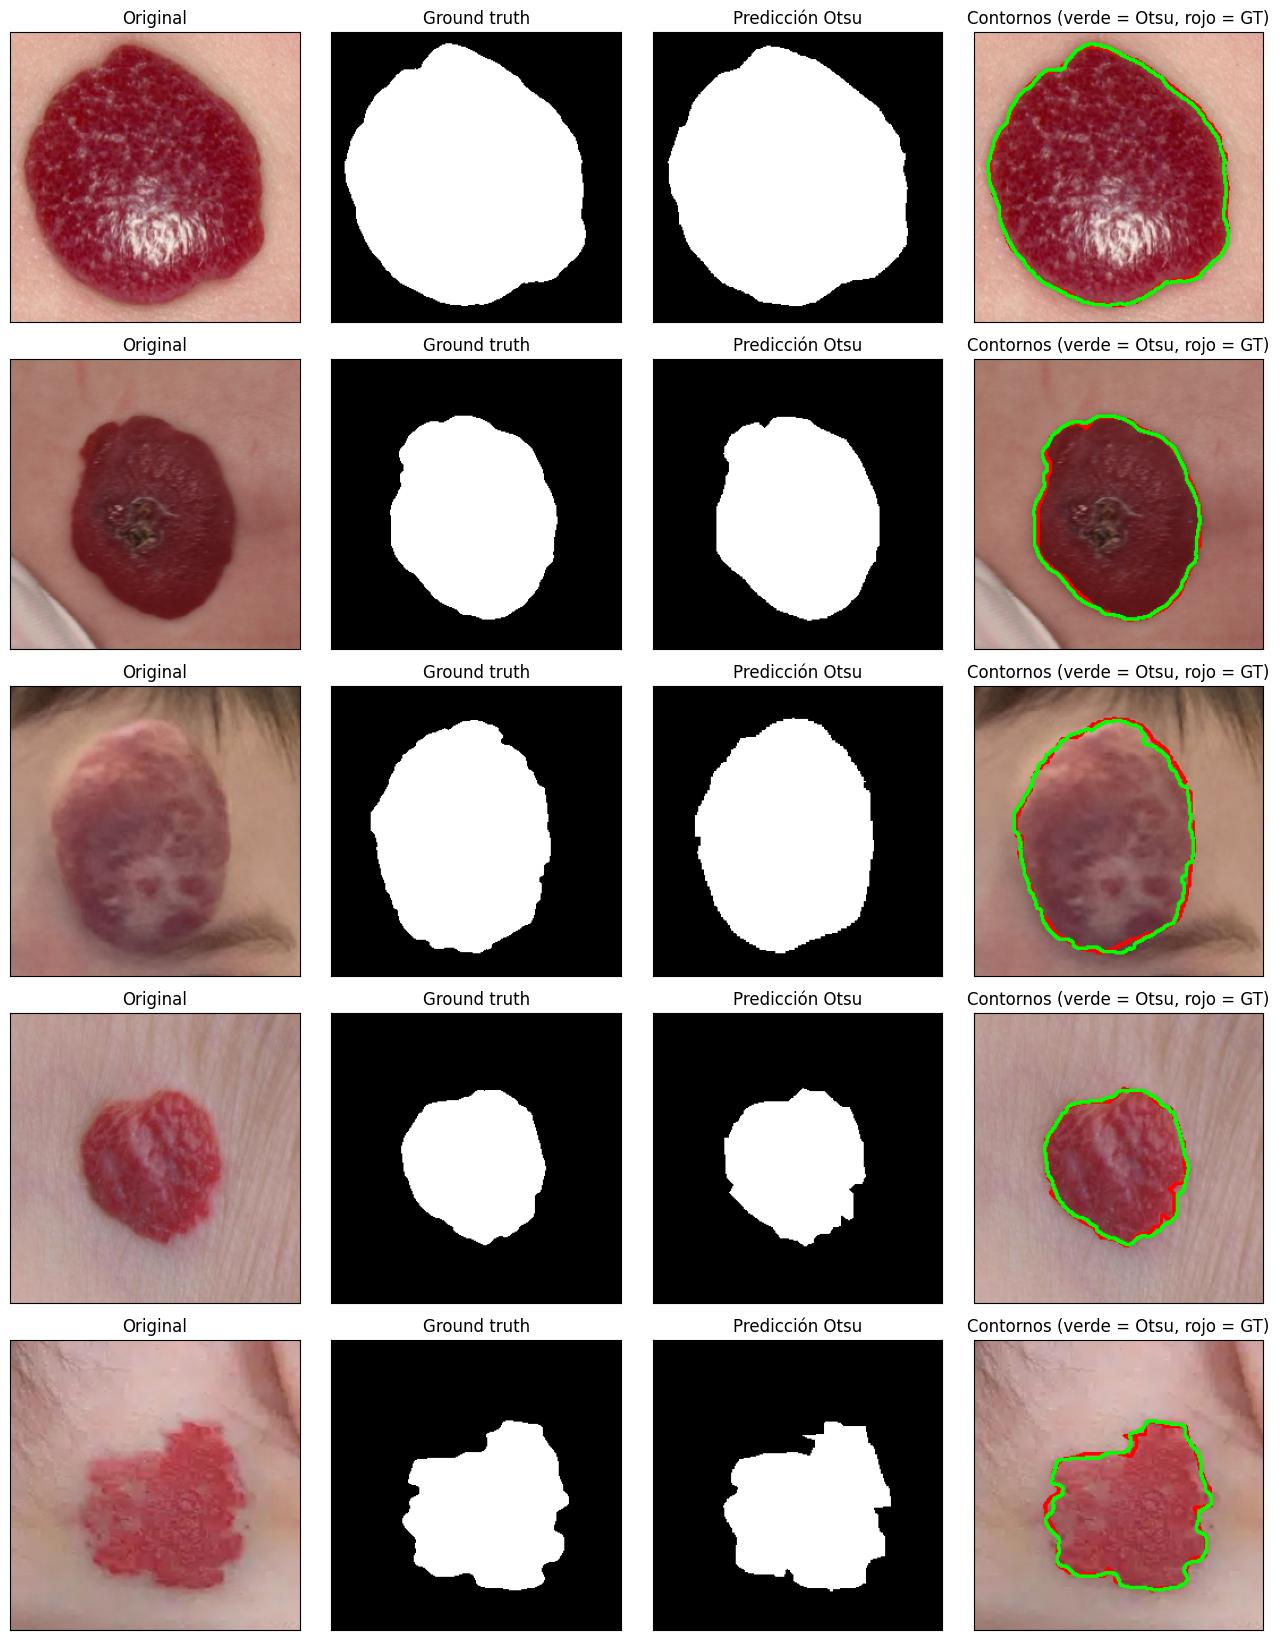

In [66]:
if GUARDAR:
    os.makedirs(CARPETA_SALIDA, exist_ok=True)

# Índices que superan el umbral, de mejor a peor Dice
buenas = [i for i in range(N) if dice_oof[i] > UMBRAL_DICE]
buenas.sort(key=lambda i: -dice_oof[i])

mostrar = buenas if MAX_MOSTRAR is None else buenas[:MAX_MOSTRAR]
if MAX_MOSTRAR is not None and len(buenas) > MAX_MOSTRAR:

  if not buenas:
    print("\nNinguna imagen supera el umbral.")
  else:
    n = len(mostrar)
    fig, axes = plt.subplots(n, 4, figsize=(13, 3.3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for fila, i in enumerate(mostrar):
        img, gt, seg = imagenes[i], mascaras[i], seg_oof[i]
        ax = axes[fila]
        ax[0].imshow(img);              ax[0].set_title("Original")
        ax[1].imshow(seg, cmap="gray"); ax[1].set_title("Ground truth")
        ax[2].imshow(gt,  cmap="gray"); ax[2].set_title("Predicción Otsu")
        ax[3].imshow(dibujar_contornos(img, seg, gt))
        ax[3].set_title("Contornos (verde = Otsu, rojo = GT)")
        for col in range(4):
            ax[col].set_xticks([]); ax[col].set_yticks([])

    plt.tight_layout()
    if GUARDAR:
        ruta_png = os.path.join(CARPETA_SALIDA, "resultados_otsu_kfold.png")
        plt.savefig(ruta_png, dpi=200, bbox_inches="tight", facecolor="white")
        print(f"Figura guardada en {ruta_png}")
    plt.show()